# 00_데이터 경로 및 구조 파악

In [ ]:
import os
import sys

print(f"OS: {sys.platform}")
print(f"현재 경로: {os.getcwd()}")

# 경로 존재 직접 확인
test_paths = [
    r"D:\git\01_mdls_ds8_open\08_dl\260318_dl_DKTC\00_data",  # Windows
    "/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data",  # Docker
]

for p in test_paths:
    print(f"{p} → 존재: {os.path.exists(p)}")

OS: linux
현재 경로: /home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC
D:\git\01_mdls_ds8_open\08_dl\260318_dl_DKTC\00_data → 존재: False
/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data → 존재: True


In [12]:
def show_structure(base_path, max_depth=10):
    for root, dirs, files in os.walk(base_path):
        depth = root.replace(base_path, "").count(os.sep)
        if depth > max_depth:
            dirs.clear()  # 더 깊은 탐색도 차단 (성능)
            continue
        indent = "  " * depth
        folder_name = os.path.basename(root) or base_path
        print(f"{indent}{folder_name}/")

        # 최대 깊이이거나 하위 디렉토리 없는 말단 폴더면 파일 요약
        if depth == max_depth or not dirs:
            if files:
                exts = {}
                for f in files:
                    ext = os.path.splitext(f)[1] or "(확장자없음)"
                    exts[ext] = exts.get(ext, 0) + 1
                print(f"{indent}  → 파일: {exts}")


base = r"/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data"

datasets = [
    "020.주제별 텍스트 일상 대화 데이터",
    "044.페르소나 대화",
    "011.일상대화 한국어 멀티세션 데이터",
]

for dataset in datasets:
    path = os.path.join(base, dataset)
    print(f"\n{'='*50}")
    print(f"데이터셋: {dataset}")
    print(f"경로 존재: {os.path.exists(path)}")
    show_structure(path)


데이터셋: 020.주제별 텍스트 일상 대화 데이터
경로 존재: True
020.주제별 텍스트 일상 대화 데이터/
  Training/
    → 파일: {'.json': 87690, '.zip': 8}
  Validation/
    → 파일: {'.json': 10962, '.zip': 5}

데이터셋: 044.페르소나 대화
경로 존재: True
044.페르소나 대화/
  Training/
    → 파일: {'.json': 25572, '.zip': 20}
  Validation/
    → 파일: {'.json': 3196, '.zip': 20}

데이터셋: 011.일상대화 한국어 멀티세션 데이터
경로 존재: True
011.일상대화 한국어 멀티세션 데이터/
  Training/
    → 파일: {'.json': 49206, '.zip': 3}
  Validation/
    → 파일: {'.json': 6149, '.zip': 3}


# 01_JSON 구조 확인

In [4]:
import os
import json
from collections import defaultdict


# 유틸리티
def _schema(obj, depth: int = 0, max_depth: int = 4):
    """
    JSON 객체의 스키마를 재귀적으로 추출.
    반환 형태 예시: {"key1": "str", "key2": ["{'turn': 'str', 'text': 'str'}"]}
    """
    if depth >= max_depth:
        return "..."

    if isinstance(obj, dict):
        return {k: _schema(v, depth + 1, max_depth) for k, v in obj.items()}
    elif isinstance(obj, list):
        if not obj:
            return ["empty"]
        # 첫 항목의 스키마만 대표로 추출
        return [_schema(obj[0], depth + 1, max_depth)]
    else:
        return type(obj).__name__


def _flat_keys(obj, prefix: str = ""):
    """
    중첩 dict/list를 '.' 구분 플랫 키로 변환.
    예: {"info": {"topic": "..."}} → {"info.topic"}
    리스트는 [0]으로 한 단계만 진입.
    """
    keys = set()
    if isinstance(obj, dict):
        for k, v in obj.items():
            full = f"{prefix}.{k}" if prefix else k
            keys.add(full)
            keys |= _flat_keys(v, full)
    elif isinstance(obj, list) and obj and isinstance(obj[0], (dict, list)):
        keys |= _flat_keys(obj[0], f"{prefix}[]")
    return keys


def _sample_text(obj, char_limit: int = 600):
    """
    JSON 객체를 보기 좋게 출력하되, 리스트는 첫 2개 항목만,
    문자열 값은 80자로 잘라서 전체 구조가 보이도록 함.
    """
    def _trim(o, depth=0):
        if depth > 5:
            return "..."
        if isinstance(o, dict):
            return {k: _trim(v, depth + 1) for k, v in o.items()}
        elif isinstance(o, list):
            trimmed = [_trim(item, depth + 1) for item in o[:2]]
            if len(o) > 2:
                trimmed.append(f"... +{len(o)-2}개")
            return trimmed
        elif isinstance(o, str) and len(o) > 80:
            return o[:77] + "..."
        return o

    text = json.dumps(_trim(obj), ensure_ascii=False, indent=2)
    if len(text) > char_limit:
        return text[:char_limit] + "\n  ... (truncated)"
    return text



# 메인 함수
def inspect_json_structure(
    base_path: str,
    dataset_dir: str,
    samples_per_folder: int = 1,
    max_folders: int = 5,
):
    """
    base_path/dataset_dir 아래 JSON 파일의 구조를 폴더별로 탐색.

    - 폴더별로 samples_per_folder개씩 샘플링 (스키마가 폴더마다 다를 수 있으므로)
    - 스키마 재귀 추출 + 플랫 키 목록
    - 전체 요약: 고유 스키마 수, 공통/차이 키
    """
    target = os.path.join(base_path, dataset_dir)

    if not os.path.isdir(target):
        print(f"[오류] 디렉토리 없음: {target}")
        return {}

    # 폴더별 JSON 수집
    folder_map = defaultdict(list)  # {folder_path: [json_paths]}
    for root, dirs, files in os.walk(target):
        for f in files:
            if f.lower().endswith(".json"):
                folder_map[root].append(os.path.join(root, f))

    total_files = sum(len(v) for v in folder_map.values())
    print("=" * 60)
    print(f"[{dataset_dir}]")
    print(f"  JSON 파일 수: {total_files}개  |  폴더 수: {len(folder_map)}개")
    print("=" * 60)

    if not folder_map:
        print("  → JSON 파일 없음\n")
        return {}

    # 폴더별 샘플링 & 스키마 추출
    all_schemas = []       # (folder_short, schema_dict, flat_keys)
    folder_items = sorted(folder_map.items())

    for fi, (folder, json_list) in enumerate(folder_items):
        if fi >= max_folders:
            remaining = len(folder_items) - max_folders
            print(f"\n  ... +{remaining}개 폴더 생략 (max_folders={max_folders})")
            break

        rel_folder = os.path.relpath(folder, target)
        print(f"\n── 폴더: {rel_folder}  ({len(json_list)}개 파일) ──")

        for si in range(min(samples_per_folder, len(json_list))):
            jf = json_list[si]
            try:
                with open(jf, "r", encoding="utf-8") as f:
                    data = json.load(f)
            except (json.JSONDecodeError, UnicodeDecodeError) as e:
                print(f"  [읽기 실패] {os.path.basename(jf)}: {e}")
                continue

            top_type = type(data).__name__
            sample = data[0] if isinstance(data, list) and data else data

            schema = _schema(sample)
            flat = _flat_keys(sample)
            all_schemas.append((rel_folder, schema, flat))

            print(f"  파일: {os.path.basename(jf)}")
            print(f"  최상위 타입: {top_type}", end="")
            if isinstance(data, list):
                print(f"  |  길이: {len(data)}", end="")
            print()

            print(f"  스키마:")
            schema_str = json.dumps(schema, ensure_ascii=False, indent=4)
            for line in schema_str.split("\n"):
                print(f"    {line}")

            print(f"  샘플:")
            for line in _sample_text(sample).split("\n"):
                print(f"    {line}")

    # 데이터셋 내 스키마 일관성 요약
    if len(all_schemas) > 1:
        print(f"\n── 스키마 일관성 검사 ──")
        key_sets = [s[2] for s in all_schemas]
        common = set.intersection(*key_sets)
        all_keys = set.union(*key_sets)
        diff = all_keys - common

        print(f"  공통 키 ({len(common)}개): {sorted(common)}")
        if diff:
            print(f"  차이 키 ({len(diff)}개): {sorted(diff)}")
            for folder, _, flat in all_schemas:
                unique = flat - common
                if unique:
                    print(f"    {folder} 고유: {sorted(unique)}")
        else:
            print(f"  → 모든 폴더 스키마 동일")

    print()
    return {s[0]: s[2] for s in all_schemas}



# 실행 + 크로스 데이터셋 비교
if __name__ == "__main__":
    base = "/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data"

    datasets = [
        "020.주제별 텍스트 일상 대화 데이터",
        "044.페르소나 대화",
        "011.일상대화 한국어 멀티세션 데이터",
    ]

    dataset_keys = {}  # {dataset_dir: set(all_flat_keys)}

    for ds in datasets:
        result = inspect_json_structure(base, ds, samples_per_folder=1, max_folders=5)
        if result:
            merged = set()
            for keys in result.values():
                merged |= keys
            dataset_keys[ds] = merged

    # 크로스 데이터셋 비교
    if len(dataset_keys) > 1:
        print("=" * 60)
        print("크로스 데이터셋 스키마 비교")
        print("=" * 60)

        all_ds_keys = list(dataset_keys.values())
        cross_common = set.intersection(*all_ds_keys)
        cross_all = set.union(*all_ds_keys)

        print(f"\n  전체 데이터셋 공통 키: {sorted(cross_common) if cross_common else '없음'}")
        print(f"  전체 고유 키 수: {len(cross_all)}개\n")

        for ds, keys in dataset_keys.items():
            unique = keys - cross_common
            ds_short = os.path.basename(ds) if os.sep in ds else ds
            print(f"  [{ds_short}]")
            print(f"    전체 키 수: {len(keys)}개")
            if unique:
                print(f"    고유 키: {sorted(unique)}")
            print()

        print("  → 공통 키가 없으면 데이터셋별 매핑 함수가 필요합니다.")
        print("    (대화 텍스트 필드, 주제 레이블 필드를 각각 식별 후 통합)")
        print()

[020.주제별 텍스트 일상 대화 데이터]
  JSON 파일 수: 98652개  |  폴더 수: 2개

── 폴더: Training  (87690개 파일) ──
  파일: BAND_100_02.json
  최상위 타입: dict
  스키마:
    {
        "dataset": {
            "identifier": "int",
            "name": "str",
            "src_path": "str",
            "label_path": "str",
            "category": "int",
            "type": "int"
        },
        "licenses": {
            "name": "str",
            "url": "str"
        },
        "info": [
            {
                "id": "int",
                "filename": "str",
                "title": "str",
                "mediatype": "str",
                "medianame": "str",
                "category": "str",
                "date": "str",
                "size": "int",
                "annotations": {
                    "subject": "...",
                    "speaker_type": "...",
                    "size": "...",
                    "word_size": "...",
                    "text": "...",
                    "lines": "..."
     

# 02_csv 파일 생성

In [15]:
# =============================================================================
# 일반 대화 데이터 → DKTC 양식 CSV 변환
# 
# DKTC train.csv 양식: id, label_name, conversation, label
#   - conversation: 발화를 \n으로 연결한 문자열
#   - label: 4 (일반 대화)
#   - label_name: "일반 대화"
#
# 대상 데이터셋 3종:
#   1) 020.주제별 텍스트 일상 대화 데이터  → info[].annotations.lines[].norm_text
#   2) 044.페르소나 대화                   → sessionInfo[].dialog[].utterance
#   3) 011.일상대화 한국어 멀티세션 데이터   → sessionInfo[].dialog[].utterance
# =============================================================================

import json
import os
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ─────────────────────────────────────────────
# 0. 경로 설정
# ─────────────────────────────────────────────
BASE = "/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data"
OUTPUT_PATH = "data/normal_conversations.csv"   # 출력 경로

# 각 데이터셋 경로 (Training만 사용 — Validation은 DKTC 자체 분할에서 처리)
DATASETS = {
    "020": os.path.join(BASE, "020.주제별 텍스트 일상 대화 데이터", "Training"),
    "044": os.path.join(BASE, "044.페르소나 대화", "Training"),
    "011": os.path.join(BASE, "011.일상대화 한국어 멀티세션 데이터", "Training"),
}

In [16]:
# ─────────────────────────────────────────────
# 1. 데이터셋별 파싱 함수
# ─────────────────────────────────────────────
 
def parse_020(filepath: str) -> list[str]:
    """
    020.주제별 텍스트 일상 대화 데이터 (BAND 형식)
    구조: data["info"][i]["annotations"]["lines"][j]["norm_text"]
    """
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    conversations = []
    for item in data.get("info", []):
        lines = item.get("annotations", {}).get("lines", [])
        if not lines:
            continue
        turns = [line["norm_text"] for line in lines if line.get("norm_text")]
        if len(turns) >= 2:  # 최소 2턴
            conversations.append("\n".join(turns))
    
    return conversations
 
 
def parse_044(filepath: str) -> list[str]:
    """
    044.페르소나 대화
    구조: data["utterances"][i]["text"]
    전체가 하나의 대화 — 각 utterance가 한 턴
    """
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    utterances = data.get("utterances", [])
    if not utterances:
        return []
    
    turns = [utt["text"].strip() for utt in utterances if utt.get("text", "").strip()]
    
    if len(turns) >= 2:
        return ["\n".join(turns)]
    return []
 
def parse_011(filepath: str) -> list[str]:
    """
    011.일상대화 한국어 멀티세션 데이터
    구조: data["sessionInfo"][i]["dialog"][j]["utterance"]
    044와 동일 구조이지만 챗봇이 아닌 사람 간 대화 → 필터링 불필요
    """
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    conversations = []
    for session in data.get("sessionInfo", []):
        dialog = session.get("dialog", [])
        if not dialog:
            continue
        turns = [utt["utterance"].strip() for utt in dialog if utt.get("utterance", "").strip()]
        if len(turns) >= 2:
            conversations.append("\n".join(turns))
    
    return conversations
 
 
# 파서 매핑
PARSERS = {
    "020": parse_020,
    "044": parse_044,
    "011": parse_011,
}

In [17]:
# ─────────────────────────────────────────────
# 2. 전체 데이터 로드
# ─────────────────────────────────────────────
all_conversations = []
stats = {}

for ds_key, ds_path in DATASETS.items():
    parser = PARSERS[ds_key]
    
    # JSON 파일 목록
    json_files = list(Path(ds_path).rglob("*.json"))
    print(f"\n[{ds_key}] {ds_path}")
    print(f"  JSON 파일 수: {len(json_files)}")
    
    ds_conversations = []
    errors = 0
    
    for jf in tqdm(json_files, desc=f"  {ds_key} 파싱"):
        try:
            convos = parser(str(jf))
            ds_conversations.extend(convos)
        except (json.JSONDecodeError, KeyError, TypeError) as e:
            errors += 1
            if errors <= 3:  # 처음 3건만 출력
                print(f"  [에러] {jf.name}: {e}")
    
    stats[ds_key] = {"files": len(json_files), "conversations": len(ds_conversations), "errors": errors}
    all_conversations.extend(ds_conversations)
    print(f"  → 대화 수: {len(ds_conversations)}개, 에러: {errors}건")





[020] /home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data/020.주제별 텍스트 일상 대화 데이터/Training
  JSON 파일 수: 87690


  020 파싱: 100%|██████████| 87690/87690 [02:59<00:00, 488.30it/s]


  → 대화 수: 87675개, 에러: 0건

[044] /home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data/044.페르소나 대화/Training
  JSON 파일 수: 25572


  044 파싱: 100%|██████████| 25572/25572 [00:51<00:00, 496.40it/s]


  → 대화 수: 25572개, 에러: 0건

[011] /home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data/011.일상대화 한국어 멀티세션 데이터/Training
  JSON 파일 수: 49206


  011 파싱: 100%|██████████| 49206/49206 [02:20<00:00, 350.09it/s]

  → 대화 수: 122613개, 에러: 0건


In [19]:
# 파싱 결과 확인

datasets = {
    "020": "/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data/020.주제별 텍스트 일상 대화 데이터/Training",
    "044": "/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data/044.페르소나 대화/Training",
    "011": "/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data/011.일상대화 한국어 멀티세션 데이터/Training",
}

for ds_key, ds_path in datasets.items():
    sample_file = next(Path(ds_path).rglob("*.json"))
    with open(sample_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    print(f"\n{'='*50}")
    print(f"[{ds_key}] {sample_file.name}")
    print(f"  최상위 키: {list(data.keys())}")
    
    for key, val in data.items():
        t = type(val).__name__
        if isinstance(val, list):
            print(f"  {key}: list[{len(val)}]")
            if val and isinstance(val[0], dict):
                print(f"    [0] 키: {list(val[0].keys())[:8]}")
        elif isinstance(val, dict):
            print(f"  {key}: dict, 키: {list(val.keys())[:8]}")
        else:
            print(f"  {key}: {t} = {str(val)[:80]}")
    
    # ── 대화 텍스트 미리보기 ──
    # 020: info가 list인 경우
    if "info" in data and isinstance(data["info"], list):
        item = data["info"][0]
        lines = item.get("annotations", {}).get("lines", [])
        preview = [l.get("norm_text", "") for l in lines[:3]]
        print(f"  미리보기 (info→lines→norm_text): {preview}")
    
    # 020: info가 dict인 경우
    elif "info" in data and isinstance(data["info"], dict):
        print(f"  info가 dict임! 키: {list(data['info'].keys())[:10]}")
    
    # 044, 011: sessionInfo
    if "sessionInfo" in data and isinstance(data["sessionInfo"], list):
        session = data["sessionInfo"][0]
        dialog = session.get("dialog", [])
        preview = [u.get("utterance", "") for u in dialog[:3]]
        print(f"  미리보기 (sessionInfo→dialog→utterance): {preview}")
    
    # 둘 다 없으면 후보 탐색
    if "sessionInfo" not in data and "info" not in data:
        print(f"  ⚠️ sessionInfo도 info도 없음! 전체 키 다시 확인")


[020] BAND_100_02.json
  최상위 키: ['dataset', 'licenses', 'info']
  dataset: dict, 키: ['identifier', 'name', 'src_path', 'label_path', 'category', 'type']
  licenses: dict, 키: ['name', 'url']
  info: list[1]
    [0] 키: ['id', 'filename', 'title', 'mediatype', 'medianame', 'category', 'date', 'size']
  미리보기 (info→lines→norm_text): ['너희 집 근처에는 병원 있어?', '응, 난 엄청 근처에 있어.', '나는 차 타고 20분 거리에 있어.']

[044] Personas_가족_1.json
  최상위 키: ['info', 'utterances']
  info: dict, 키: ['category', 'evaluation', 'id', 'name', 'personas', 'topic', 'votes']
  utterances: list[16]
    [0] 키: ['persona_id', 'terminate', 'text', 'utterance_id']
  info가 dict임! 키: ['category', 'evaluation', 'id', 'name', 'personas', 'topic', 'votes']

[011] DAILY-003794-AP600003-WZ000002-02_03_04-S2.json
  최상위 키: ['FileInfo', 'participantsInfo', 'multisessionInfo', 'personaInfo', 'topicInfo', 'sessionInfo']
  FileInfo: dict, 키: ['filename', 'sessionLevel']
  participantsInfo: dict, 키: ['numberOfParticipants', 'speaker1', 'speaker2

In [20]:
# ─────────────────────────────────────────────
# 3. DKTC 양식 DataFrame 생성
# ─────────────────────────────────────────────
normal_df = pd.DataFrame({
    "id": range(10000, 10000 + len(all_conversations)),
    "label_name": "일반 대화",
    "conversation": all_conversations,
    "label": 4
})

# 기본 정제
before = len(normal_df)
normal_df = normal_df[normal_df["conversation"].str.len() > 0]           # 빈 텍스트 제거
normal_df = normal_df.drop_duplicates(subset=["conversation"])            # 완전 중복 제거
normal_df = normal_df.reset_index(drop=True)
normal_df["id"] = range(10000, 10000 + len(normal_df))

print(f"[정제] {before} → {len(normal_df)} ({before - len(normal_df)}개 제거)")


[정제] 235860 → 235508 (352개 제거)


# 03_데이터 확인

In [22]:
# =============================================================================
# 일반 대화 데이터 EDA & 시각화
# normal_conversations.csv 로드 후 독립 실행 가능
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from collections import Counter
import re
import os


# ─────────────────────────────────────────────
# 0. 한글 폰트 설정
# ─────────────────────────────────────────────
# Docker(Linux) 환경
font_candidates = [
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf",
    "/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf",
    "/usr/share/fonts/noto-cjk/NotoSansCJK-Regular.ttc",
]

font_path = None
for fc in font_candidates:
    if os.path.exists(fc):
        font_path = fc
        break

if font_path:
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams["font.family"] = font_name
else:
    # Windows 환경
    plt.rcParams["font.family"] = "Malgun Gothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 120

In [ ]:
# ─────────────────────────────────────────────
# 1. 데이터 로드 (독립 실행 시)
# ─────────────────────────────────────────────
# 위 변환 코드에서 이어 실행하면 normal_df가 이미 있으므로 이 블록 스킵
# 독립 실행 시 아래 주석 해제
# normal_df = pd.read_csv("data/normal_conversations.csv")


In [23]:
# ─────────────────────────────────────────────
# 2. 기본 피처 추출
# ─────────────────────────────────────────────
normal_df["n_turns"] = normal_df["conversation"].apply(lambda x: len([t for t in str(x).split("\n") if t.strip()]))
normal_df["total_chars"] = normal_df["conversation"].apply(lambda x: len(str(x)))
normal_df["avg_turn_len"] = normal_df.apply(
    lambda row: row["total_chars"] / row["n_turns"] if row["n_turns"] > 0 else 0, axis=1
)
# 단어 수 (공백 기준 근사치)
normal_df["n_words"] = normal_df["conversation"].apply(lambda x: len(str(x).split()))


In [24]:
# ─────────────────────────────────────────────
# 3. 텍스트 통계 요약
# ─────────────────────────────────────────────
print("=" * 60)
print("일반 대화 데이터 개요")
print("=" * 60)
print(f"  총 대화 수: {len(normal_df):,}개")
print(f"  중복 대화: {normal_df['conversation'].duplicated().sum()}개")
print()

desc_cols = ["n_turns", "total_chars", "avg_turn_len", "n_words"]
desc = normal_df[desc_cols].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
print("  수치 요약:")
print(desc.round(1).to_string())
print()

# DKTC 위협 데이터와 비교 기준 (원본 train.csv 기준 대략적 값)
print("  ⚠️ DKTC 위협 대화 참고값 (비교용):")
print("     위협 대화 평균 턴 수: ~8턴")
print("     위협 대화 평균 글자 수: ~200자")
print("     → 일반 대화 분포가 이 범위와 크게 다르면 길이 편향 발생 가능")
print()

일반 대화 데이터 개요
  총 대화 수: 235,508개
  중복 대화: 0개

  수치 요약:
        n_turns  total_chars  avg_turn_len   n_words
count  235508.0     235508.0      235508.0  235508.0
mean       16.3        720.2          44.4     170.5
std         3.9        359.6          21.3      80.2
min         2.0         26.0           6.9       7.0
25%        14.0        360.0          21.8      95.0
50%        16.0        804.0          49.7     184.0
75%        16.0       1006.0          61.6     232.0
90%        20.0       1159.0          70.2     270.0
95%        23.0       1255.0          75.5     295.0
99%        31.0       1445.0          86.5     345.0
max       108.0       2360.0         136.8     585.0

  ⚠️ DKTC 위협 대화 참고값 (비교용):
     위협 대화 평균 턴 수: ~8턴
     위협 대화 평균 글자 수: ~200자
     → 일반 대화 분포가 이 범위와 크게 다르면 길이 편향 발생 가능



findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
/tmp/ipykernel_287060/1368900854.py:83: UserWarning: Glyph 53556 (\N{HANGUL SYLLABLE TEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_287060/1368900854.py:83: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 'Malgun Gothic' not found.
findfont: Font family 

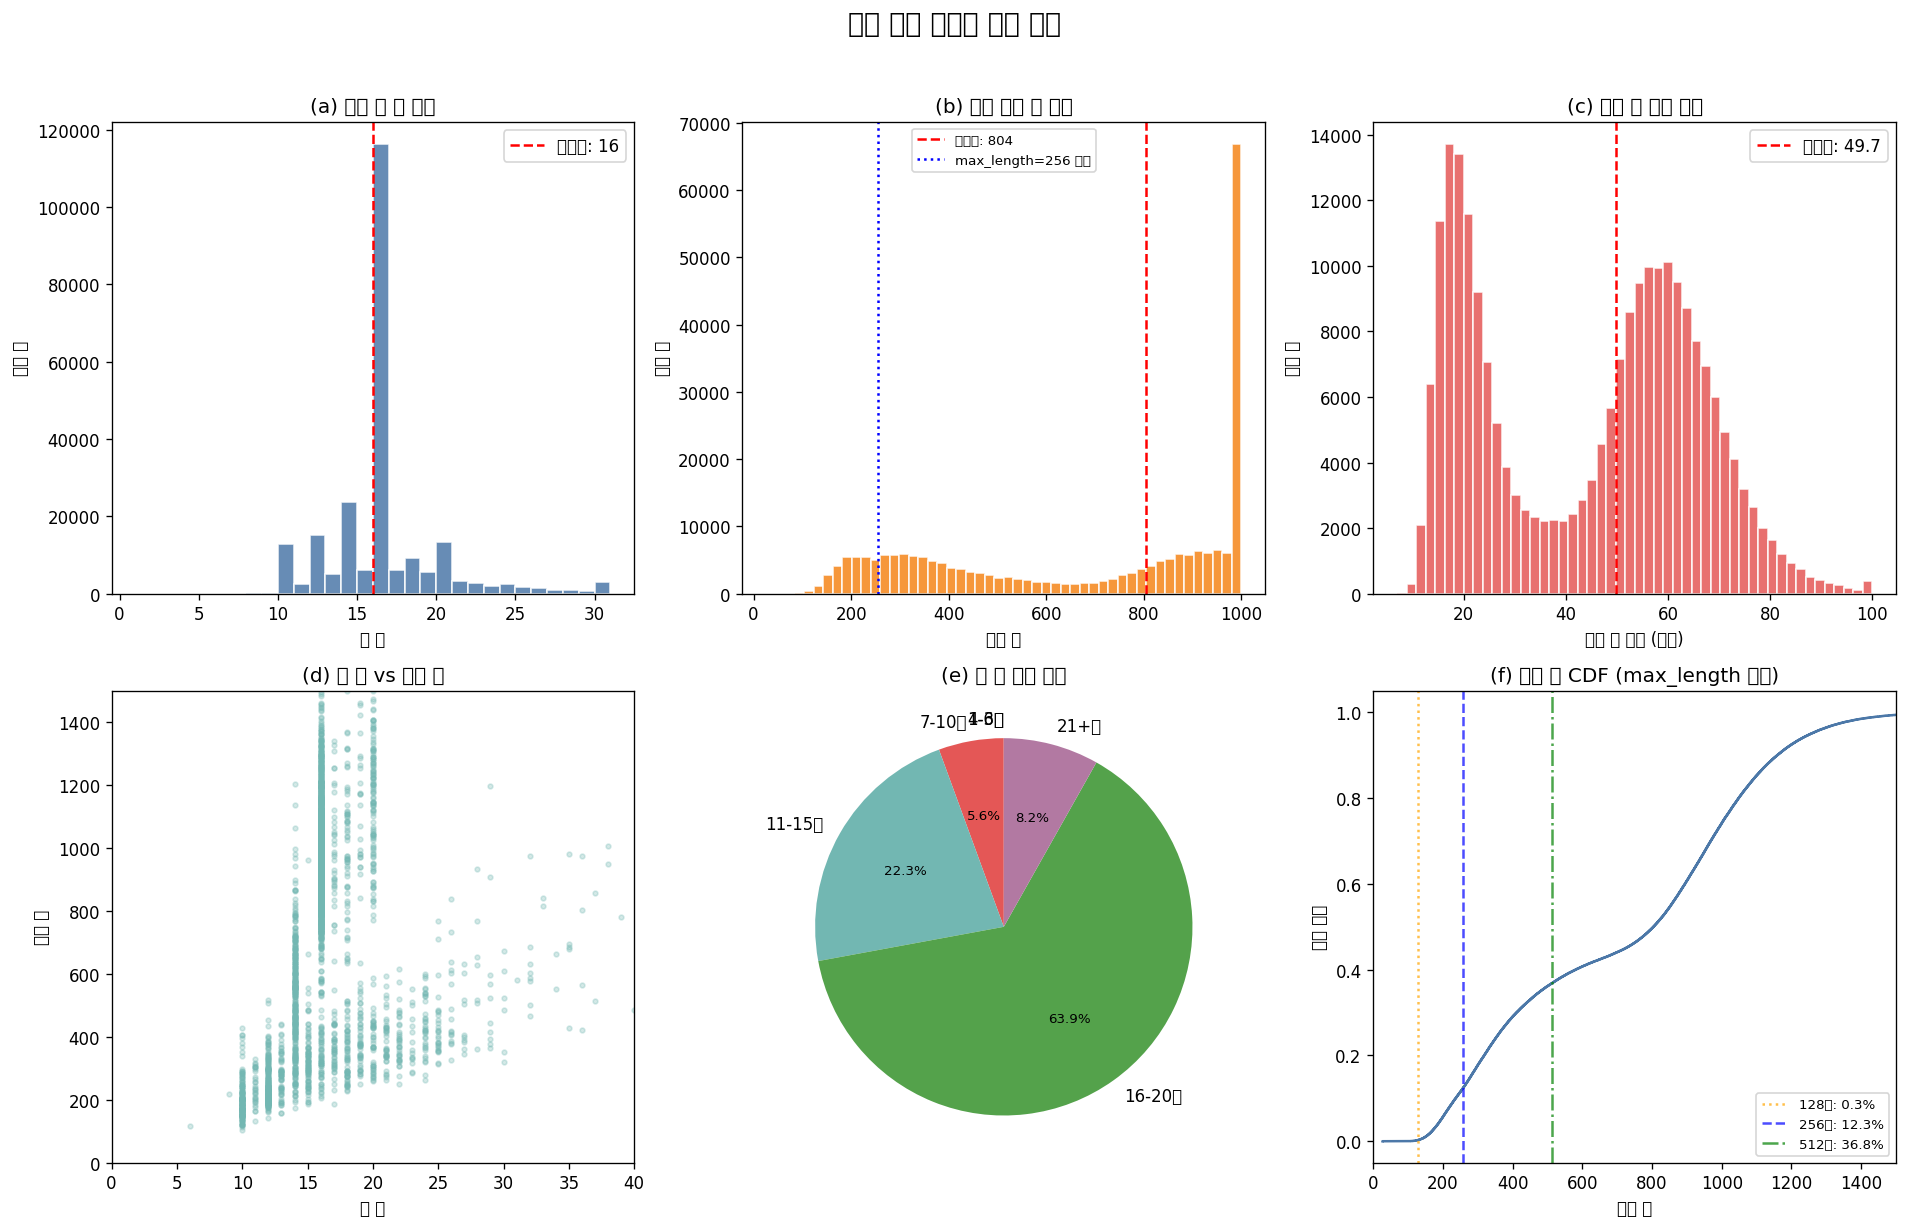

  → 저장: data/normal_eda_distribution.png


In [25]:
# ─────────────────────────────────────────────
# 4. 시각화
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("일반 대화 데이터 분포 분석", fontsize=16, fontweight="bold", y=1.02)

# (a) 턴 수 분포
ax = axes[0, 0]
turn_counts = normal_df["n_turns"].clip(upper=30)  # 30턴 이상은 묶어서 표시
ax.hist(turn_counts, bins=range(1, 32), color="#4C78A8", edgecolor="white", alpha=0.85)
ax.axvline(normal_df["n_turns"].median(), color="red", linestyle="--", label=f'중앙값: {normal_df["n_turns"].median():.0f}')
ax.set_xlabel("턴 수")
ax.set_ylabel("대화 수")
ax.set_title("(a) 대화 턴 수 분포")
ax.legend()

# (b) 글자 수 분포
ax = axes[0, 1]
char_counts = normal_df["total_chars"].clip(upper=1000)
ax.hist(char_counts, bins=50, color="#F58518", edgecolor="white", alpha=0.85)
ax.axvline(normal_df["total_chars"].median(), color="red", linestyle="--", label=f'중앙값: {normal_df["total_chars"].median():.0f}')
ax.axvline(256, color="blue", linestyle=":", label="max_length=256 기준")
ax.set_xlabel("글자 수")
ax.set_ylabel("대화 수")
ax.set_title("(b) 대화 글자 수 분포")
ax.legend(fontsize=8)

# (c) 평균 턴 길이 분포
ax = axes[0, 2]
avg_lens = normal_df["avg_turn_len"].clip(upper=100)
ax.hist(avg_lens, bins=50, color="#E45756", edgecolor="white", alpha=0.85)
ax.axvline(normal_df["avg_turn_len"].median(), color="red", linestyle="--", label=f'중앙값: {normal_df["avg_turn_len"].median():.1f}')
ax.set_xlabel("평균 턴 길이 (글자)")
ax.set_ylabel("대화 수")
ax.set_title("(c) 평균 턴 길이 분포")
ax.legend()

# (d) 턴 수 vs 글자 수 산점도
ax = axes[1, 0]
sample_idx = np.random.choice(len(normal_df), min(3000, len(normal_df)), replace=False)
ax.scatter(
    normal_df.iloc[sample_idx]["n_turns"],
    normal_df.iloc[sample_idx]["total_chars"],
    alpha=0.3, s=8, color="#72B7B2"
)
ax.set_xlabel("턴 수")
ax.set_ylabel("글자 수")
ax.set_title("(d) 턴 수 vs 글자 수")
ax.set_xlim(0, 40)
ax.set_ylim(0, 1500)

# (e) 턴 수 구간별 비율 (파이 차트)
ax = axes[1, 1]
bins = [0, 3, 6, 10, 15, 20, float("inf")]
labels = ["1-3턴", "4-6턴", "7-10턴", "11-15턴", "16-20턴", "21+턴"]
turn_bins = pd.cut(normal_df["n_turns"], bins=bins, labels=labels)
bin_counts = turn_bins.value_counts().sort_index()
colors = ["#4C78A8", "#F58518", "#E45756", "#72B7B2", "#54A24B", "#B279A2"]
wedges, texts, autotexts = ax.pie(
    bin_counts.values, labels=bin_counts.index,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 3 else "",
    colors=colors, startangle=90
)
for t in autotexts:
    t.set_fontsize(8)
ax.set_title("(e) 턴 수 구간 비율")

# (f) 글자 수 누적분포 (CDF) — max_length 결정 참고
ax = axes[1, 2]
sorted_chars = np.sort(normal_df["total_chars"].values)
cdf = np.arange(1, len(sorted_chars) + 1) / len(sorted_chars)
ax.plot(sorted_chars, cdf, color="#4C78A8", linewidth=1.5)
# 주요 임계점 표시
for threshold, color, ls in [(128, "orange", ":"), (256, "blue", "--"), (512, "green", "-.")]:
    pct = (normal_df["total_chars"] <= threshold).mean() * 100
    ax.axvline(threshold, color=color, linestyle=ls, alpha=0.7, label=f"{threshold}자: {pct:.1f}%")
ax.set_xlabel("글자 수")
ax.set_ylabel("누적 비율")
ax.set_title("(f) 글자 수 CDF (max_length 참고)")
ax.legend(fontsize=8)
ax.set_xlim(0, 1500)

plt.tight_layout()
plt.savefig("data/normal_eda_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("  → 저장: data/normal_eda_distribution.png")

In [26]:
# ─────────────────────────────────────────────
# 5. 데이터셋 출처별 분포 비교 (선택적)
# ─────────────────────────────────────────────
# 변환 코드에서 출처 태그를 남겨둔 경우 사용
# 여기서는 대화 특성으로 간접 비교

print("\n" + "=" * 60)
print("이상치 / 주의 구간")
print("=" * 60)

# 극단 케이스
very_short = normal_df[normal_df["n_turns"] <= 2]
very_long = normal_df[normal_df["total_chars"] > 1000]
print(f"  2턴 이하 (너무 짧음): {len(very_short):,}개 ({len(very_short)/len(normal_df)*100:.1f}%)")
print(f"  1000자 초과 (토크나이저 잘림 위험): {len(very_long):,}개 ({len(very_long)/len(normal_df)*100:.1f}%)")
print()

# max_length 커버리지
for ml in [128, 256, 512]:
    coverage = (normal_df["total_chars"] <= ml).mean() * 100
    print(f"  max_length={ml} → 커버리지 {coverage:.1f}%")

print()
print("  권장: max_length=256이면 대부분 커버.")
print("  1000자 초과 대화는 학습 시 잘리므로,")
print("  필요하면 긴 대화를 세션 단위로 분할하거나 제외 고려.")



이상치 / 주의 구간
  2턴 이하 (너무 짧음): 6개 (0.0%)
  1000자 초과 (토크나이저 잘림 위험): 60,650개 (25.8%)

  max_length=128 → 커버리지 0.3%
  max_length=256 → 커버리지 12.3%
  max_length=512 → 커버리지 36.8%

  권장: max_length=256이면 대부분 커버.
  1000자 초과 대화는 학습 시 잘리므로,
  필요하면 긴 대화를 세션 단위로 분할하거나 제외 고려.


In [27]:

# ─────────────────────────────────────────────
# 6. 고빈도 단어 분석 (위협 대화와 겹치는 단어 확인용)
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("고빈도 단어 Top 30 (불용어 제외)")
print("=" * 60)

# 간이 불용어
stopwords = {"나", "너", "좀", "것", "거", "이", "그", "저", "뭐", "왜", "어",
             "안", "못", "내", "네", "또", "다", "더", "잘", "진짜", "되",
             "수", "에", "를", "을", "가", "는", "은", "의", "도", "로", "에서",
             "이다", "하다", "있다", "없다", "한", "하고", "해서", "했", "하는",
             "같", "적", "대", "중", "위"}

all_text = " ".join(normal_df["conversation"].values)
# 한글만 추출
words = re.findall(r"[가-힣]{2,}", all_text)
word_counts = Counter(w for w in words if w not in stopwords)

print(f"  고유 단어 수: {len(word_counts):,}개")
print()
for word, count in word_counts.most_common(30):
    bar = "█" * min(int(count / word_counts.most_common(1)[0][1] * 30), 30)
    print(f"  {word:8s} {count:>7,}  {bar}")


# ─────────────────────────────────────────────
# 7. 최종 요약 리포트
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("최종 데이터 품질 체크리스트")
print("=" * 60)

checks = [
    ("총 대화 수 >= 500", len(normal_df) >= 500),
    ("중복 0건", normal_df["conversation"].duplicated().sum() == 0),
    ("빈 텍스트 0건", (normal_df["conversation"].str.len() == 0).sum() == 0),
    ("2턴 이하 비율 < 10%", len(very_short) / len(normal_df) < 0.1),
    ("중앙값 턴 수 >= 4", normal_df["n_turns"].median() >= 4),
    ("max_length=256 커버리지 >= 70%", (normal_df["total_chars"] <= 256).mean() >= 0.7),
]

for desc, passed in checks:
    status = "✅ PASS" if passed else "⚠️ FAIL"
    print(f"  {status}  {desc}")

print(f"\n{'='*60}")


고빈도 단어 Top 30 (불용어 제외)
  고유 단어 수: 1,635,373개

  대해       328,861  ██████████████████████████████
  키키       312,575  ████████████████████████████
  어떤       274,037  ████████████████████████
  정말       230,844  █████████████████████
  있어요      198,306  ██████████████████
  저는       195,347  █████████████████
  제가       181,647  ████████████████
  대한       170,191  ███████████████
  같아요      160,738  ██████████████
  많이       143,359  █████████████
  좋은       137,680  ████████████
  있는       135,790  ████████████
  다른       126,296  ███████████
  알고       120,268  ██████████
  너무       118,232  ██████████
  저도       109,740  ██████████
  안녕하세요    106,168  █████████
  많은        98,308  ████████
  감사합니다     89,058  ████████
  그럼        87,993  ████████
  다시        85,528  ███████
  그렇군요      78,414  ███████
  관심이       77,090  ███████
  그리고       74,250  ██████
  나는        73,871  ██████
  도움이       72,990  ██████
  요즘        72,342  ██████
  언제든지      71,511  ██████
  있습니다      70,868  

In [28]:
# ─────────────────────────────────────────────
# 7. 최종 요약 리포트
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("최종 데이터 품질 체크리스트")
print("=" * 60)
 
checks = [
    ("총 대화 수 >= 500", len(normal_df) >= 500),
    ("중복 0건", normal_df["conversation"].duplicated().sum() == 0),
    ("빈 텍스트 0건", (normal_df["conversation"].str.len() == 0).sum() == 0),
    ("2턴 이하 비율 < 10%", len(very_short) / len(normal_df) < 0.1),
    ("중앙값 턴 수 >= 4", normal_df["n_turns"].median() >= 4),
    ("max_length=256 커버리지 >= 70%", (normal_df["total_chars"] <= 256).mean() >= 0.7),
]
 
for desc, passed in checks:
    status = "✅ PASS" if passed else "⚠️ FAIL"
    print(f"  {status}  {desc}")
 
print(f"\n{'='*60}")


최종 데이터 품질 체크리스트
  ✅ PASS  총 대화 수 >= 500
  ✅ PASS  중복 0건
  ✅ PASS  빈 텍스트 0건
  ✅ PASS  2턴 이하 비율 < 10%
  ✅ PASS  중앙값 턴 수 >= 4
  ⚠️ FAIL  max_length=256 커버리지 >= 70%



In [29]:
# ── 데이터셋 출처 태깅 (섹션 2의 로드 루프 수정) ──
all_conversations = []

for ds_key, ds_path in DATASETS.items():
    parser = PARSERS[ds_key]
    json_files = list(Path(ds_path).rglob("*.json"))
    
    for jf in tqdm(json_files, desc=f"  {ds_key} 파싱"):
        try:
            convos = parser(str(jf))
            for c in convos:
                all_conversations.append({"conversation": c, "source": ds_key})
        except (json.JSONDecodeError, KeyError, TypeError):
            pass

normal_df = pd.DataFrame(all_conversations)
normal_df["label_name"] = "일반 대화"
normal_df["label"] = 4
normal_df["id"] = range(10000, 10000 + len(normal_df))

  011 파싱: 100%|██████████| 49206/49206 [02:24<00:00, 341.57it/s]


In [34]:
# ── DKTC 위협 데이터 분포 측정 ──
dktc_df = pd.read_csv("data/train.csv")  # 원본 DKTC

dktc_df["n_turns"] = dktc_df["conversation"].apply(
    lambda x: len([t for t in str(x).split("\n") if t.strip()])
)
dktc_df["total_chars"] = dktc_df["conversation"].str.len()

print("=== DKTC 위협 대화 ===")
print(f"  대화 수: {len(dktc_df)}")
print(f"  턴 수:  평균 {dktc_df['n_turns'].mean():.1f}, 중앙값 {dktc_df['n_turns'].median():.0f}")
print(f"  글자 수: 평균 {dktc_df['total_chars'].mean():.0f}, 중앙값 {dktc_df['total_chars'].median():.0f}")
print(f"  max_length=256 커버리지: {(dktc_df['total_chars'] <= 256).mean()*100:.1f}%")
print(f"  max_length=512 커버리지: {(dktc_df['total_chars'] <= 512).mean()*100:.1f}%")
print()

# ── 020 일반대화 분포 ──
df_020 = normal_df[normal_df["source"] == "020"].copy()
df_020["n_turns"] = df_020["conversation"].apply(
    lambda x: len([t for t in str(x).split("\n") if t.strip()])
)
df_020["total_chars"] = df_020["conversation"].str.len()

print("=== 020 일반대화 ===")
print(f"  대화 수: {len(df_020)}")
print(f"  턴 수:  평균 {df_020['n_turns'].mean():.1f}, 중앙값 {df_020['n_turns'].median():.0f}")
print(f"  글자 수: 평균 {df_020['total_chars'].mean():.0f}, 중앙값 {df_020['total_chars'].median():.0f}")
print(f"  max_length=256 커버리지: {(df_020['total_chars'] <= 256).mean()*100:.1f}%")
print(f"  max_length=512 커버리지: {(df_020['total_chars'] <= 512).mean()*100:.1f}%")
# ── 나란히 비교 ──
print("=== 분포 비교 ===")
for col in ["n_turns", "total_chars"]:
    print(f"\n  {col}:")
    for pct in [25, 50, 75, 90, 95]:
        d = dktc_df[col].quantile(pct/100)
        n = df_020[col].quantile(pct/100)
        print(f"    {pct}%ile  DKTC: {d:.0f}  |  020: {n:.0f}")

=== DKTC 위협 대화 ===
  대화 수: 3950
  턴 수:  평균 10.3, 중앙값 10
  글자 수: 평균 227, 중앙값 203
  max_length=256 커버리지: 70.9%
  max_length=512 커버리지: 97.3%

=== 020 일반대화 ===
  대화 수: 87675
  턴 수:  평균 16.5, 중앙값 15
  글자 수: 평균 332, 중앙값 306
  max_length=256 커버리지: 33.2%
  max_length=512 커버리지: 91.0%
=== 분포 비교 ===

  n_turns:
    25%ile  DKTC: 10  |  020: 12
    50%ile  DKTC: 10  |  020: 15
    75%ile  DKTC: 11  |  020: 20
    90%ile  DKTC: 12  |  020: 24
    95%ile  DKTC: 12  |  020: 28

  total_chars:
    25%ile  DKTC: 156  |  020: 229
    50%ile  DKTC: 203  |  020: 306
    75%ile  DKTC: 270  |  020: 395
    90%ile  DKTC: 350  |  020: 500
    95%ile  DKTC: 422  |  020: 597


# 04_csv 파일 생성

In [4]:
# =============================================================================
# 04_csv 파일 생성 (자체 완결형 — 커널 재시작 후에도 독립 실행 가능)
# 주의: 텍스트 정제(clean_text)는 여기서 하지 않음
#       DKTC와 합친 뒤 preprocessing_pipeline에서 동일 적용
# =============================================================================
import json
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# ── 1. 020 직접 파싱 ──
def parse_020(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        data = json.load(f)
    conversations = []
    for item in data.get("info", []):
        lines = item.get("annotations", {}).get("lines", [])
        if not lines:
            continue
        turns = [line["norm_text"] for line in lines if line.get("norm_text")]
        if len(turns) >= 2:
            conversations.append("\n".join(turns))
    return conversations

ds_path = Path("/home/jovyan/d/git/01_mdls_ds8_open/08_dl/260318_dl_DKTC/00_data/020.주제별 텍스트 일상 대화 데이터/Training")
json_files = list(ds_path.rglob("*.json"))
print(f"JSON 파일 수: {len(json_files)}")

all_convos = []
for jf in tqdm(json_files, desc="020 파싱"):
    try:
        all_convos.extend(parse_020(str(jf)))
    except (json.JSONDecodeError, KeyError, TypeError):
        pass

df_020 = pd.DataFrame({"conversation": all_convos})
print(f"파싱 완료: {len(df_020)}개")

# ── 2. 빈 텍스트 제거 + 중복 제거 (정제 없이 원본 기준) ──
df_020 = df_020[df_020["conversation"].str.len() > 0]
df_020 = df_020.drop_duplicates(subset=["conversation"]).reset_index(drop=True)

# ── 3. 피처 계산 ──
df_020["n_turns"] = df_020["conversation"].apply(
    lambda x: len([t for t in x.split("\n") if t.strip()])
)
df_020["total_chars"] = df_020["conversation"].str.len()

# ── 4. DKTC 양식 ──
df_020["id"] = range(10000, 10000 + len(df_020))
df_020["label_name"] = "일반 대화"
df_020["label"] = 4

# ── 5. 자연 필터링 결과 확인 ──
natural = df_020[(df_020["n_turns"] <= 14) & (df_020["total_chars"] <= 450)]
print(f"\n전체: {len(df_020)}개")
print(f"자연 필터 (턴<=14 & 글자<=450): {len(natural)}개 ({len(natural)/len(df_020)*100:.1f}%)")

# ── 6. CSV 저장 ──
save_df = df_020[["id", "label_name", "conversation", "label", "n_turns", "total_chars"]].copy()
save_df["conversation"] = save_df["conversation"].str.replace("\n", " [SEP] ")
save_df.to_csv("data/normal_020_full.csv", index=False)

# ── 7. 검증 ──
verify = pd.read_csv("data/normal_020_full.csv")
print(f"\n검증: {len(verify)}행 로드 (원본 {len(save_df)}행)")
assert len(verify) == len(save_df), "⛔ 행 수 불일치!"
print("✅ CSV 무결성 확인 완료")

JSON 파일 수: 87690


020 파싱: 100%|██████████| 87690/87690 [03:07<00:00, 467.01it/s]


파싱 완료: 87675개

전체: 87331개
자연 필터 (턴<=14 & 글자<=450): 39802개 (45.6%)

검증: 87331행 로드 (원본 87331행)
✅ CSV 무결성 확인 완료


In [6]:
df_020.head()

,conversation,n_turns,total_chars,id,label_name,label
0,"너희 집 근처에는 병원 있어?\n응, 난 엄청 근처에 있어.\n나는 차 타고 20분...",12,244,10000,일반 대화,4
1,나는 경유차가 첫차였어\n아 노후 경유차였구나\n노후 경유차면 운행이 쉽진 않지\n...,15,356,10001,일반 대화,4
2,너희 일할 때 mbti 뭐야?\n나는 해봤는데 ENTJ야.\nJ들이 꼼꼼하고 계획적...,15,282,10002,일반 대화,4
3,군대는 몇살부터 가는 걸까요?\n만 19세 이상부터 가는 걸로 알고 있는데\n20세...,12,298,10003,일반 대화,4
4,이번에 수학 수행평가 뭔지 알아?\n들었었는데 까먹었어.\n코사인 법칙 증명하는 거...,13,250,10004,일반 대화,4


In [7]:
# 필요할 때 로드 + 필터
# df = pd.read_csv("data/normal_020_full.csv")
# filtered = df[(df["n_turns"] <= 14) & (df["total_chars"] <= 450)]
# sampled = filtered.sample(n=1000, random_state=42)